#📌 Extracción

In [ ]:
import pandas as pd
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
  with open("TelecomX_Data_normalizado.json", 'r') as archivo:
      datos = json.load(archivo)
  df = pd.DataFrame(datos)
  df.head()
except Exception as e:
  print(f'Se presentó un error al cargar: {e}')

## 🕵️ Verificando datos

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7267 non-null   object 
 1   Churn             7267 non-null   object 
 2   gender            7267 non-null   object 
 3   SeniorCitizen     7267 non-null   int64  
 4   Partner           7267 non-null   object 
 5   Dependents        7267 non-null   object 
 6   tenure            7267 non-null   int64  
 7   PhoneService      7267 non-null   object 
 8   MultipleLines     7267 non-null   object 
 9   InternetService   7267 non-null   object 
 10  OnlineSecurity    7267 non-null   object 
 11  OnlineBackup      7267 non-null   object 
 12  DeviceProtection  7267 non-null   object 
 13  TechSupport       7267 non-null   object 
 14  StreamingTV       7267 non-null   object 
 15  StreamingMovies   7267 non-null   object 
 16  Contract          7267 non-null   object 


In [ ]:
df['Churn'].unique()

array(['No', 'Yes', ''], dtype=object)

In [ ]:
df.groupby('Churn').size()

,0
Churn,
,224
No,5174
Yes,1869


### 🧹 Limpieza

In [ ]:
df = df[df['Churn'] != '']
df['Churn'].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
for columna in df.columns:
  if df[columna].dtype == 'object':
      print(f"{columna}: Valores únicos en la columna '{df[columna].unique()}':")
  else:
    pass


customerID: Valores únicos en la columna '['0002-ORFBO' '0003-MKNFE' '0004-TLHLJ' ... '9992-UJOEL' '9993-LHIEB'
 '9995-HOTOH']':
Churn: Valores únicos en la columna '['No' 'Yes']':
gender: Valores únicos en la columna '['Female' 'Male']':
Partner: Valores únicos en la columna '['Yes' 'No']':
Dependents: Valores únicos en la columna '['Yes' 'No']':
PhoneService: Valores únicos en la columna '['Yes' 'No']':
MultipleLines: Valores únicos en la columna '['No' 'Yes' 'No phone service']':
InternetService: Valores únicos en la columna '['DSL' 'Fiber optic' 'No']':
OnlineSecurity: Valores únicos en la columna '['No' 'Yes' 'No internet service']':
OnlineBackup: Valores únicos en la columna '['Yes' 'No' 'No internet service']':
DeviceProtection: Valores únicos en la columna '['No' 'Yes' 'No internet service']':
TechSupport: Valores únicos en la columna '['Yes' 'No' 'No internet service']':
StreamingTV: Valores únicos en la columna '['Yes' 'No' 'No internet service']':
StreamingMovies: Valores ún

In [ ]:
import warnings
warnings.filterwarnings('ignore', category=FutureWarning)

df['Churn'] = df['Churn'].replace({'Yes': 1, 'No': 0})
df['gender'] = df['gender'].replace({'Male': 1, 'Female': 0})
df['Partner'] = df['Partner'].replace({'Yes': 1, 'No': 0})
df['Dependents'] = df['Dependents'].replace({'Yes': 1, 'No': 0})
df['PhoneService'] = df['PhoneService'].replace({'Yes': 1, 'No': 0})
df['PaperlessBilling'] = df['PaperlessBilling'].replace({'Yes': 1, 'No': 0})
df = df.drop(columns=['customerID'])

df.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
0,0,0,0,1,1,9,1,No,DSL,No,Yes,No,Yes,Yes,No,One year,1,Mailed check,65.6,593.3
1,0,1,0,0,0,9,1,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.4
2,1,1,0,0,0,4,1,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,1,Electronic check,73.9,280.85
3,1,1,1,1,0,13,1,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85
4,1,0,1,1,0,3,1,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.4


In [ ]:
df['Charges.Total'] = pd.to_numeric(df['Charges.Total'], errors='coerce')
perdidos = df['Charges.Total'].isna().sum()
print(f"Se perdieron {perdidos} valores que no se pudieron convertir")


Se perdieron 11 valores que no se pudieron convertir


In [ ]:
indice_problema = df[df['Charges.Total'].isna()].index
df.loc[indice_problema, :]

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges.Monthly,Charges.Total
975,0,0,0,1,1,0,0,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,0,Credit card (automatic),56.05,NaN
1775,0,0,0,1,1,0,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,20.00,NaN
1955,0,1,0,0,1,0,1,Yes,DSL,Yes,Yes,No,Yes,No,No,Two year,1,Bank transfer (automatic),61.90,NaN
2075,0,1,0,1,1,0,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,1,Mailed check,19.70,NaN
2232,0,1,0,0,1,0,1,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,20.25,NaN
2308,0,1,0,1,1,0,1,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,25.35,NaN
2930,0,0,0,1,1,0,1,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,0,Mailed check,73.35,NaN
3134,0,1,0,1,1,0,1,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,0,Mailed check,25.75,NaN
3203,0,0,0,1,1,0,0,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,1,Bank transfer (automatic),52.55,NaN
4169,0,0,0,1,1,0,1,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,0,Mailed check,80.85,NaN


In [ ]:
print('%',round(df['Charges.Total'].isna().sum()/df.shape[0]*100, 3))

% 0.156




---






Se decide eliminar las filas NaN de la columna 'Charges.Total' ya que representa el % 0.156









---



In [ ]:
df.dropna(subset=['Charges.Total'], inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7266
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Churn             7032 non-null   int64  
 1   gender            7032 non-null   int64  
 2   SeniorCitizen     7032 non-null   int64  
 3   Partner           7032 non-null   int64  
 4   Dependents        7032 non-null   int64  
 5   tenure            7032 non-null   int64  
 6   PhoneService      7032 non-null   int64  
 7   MultipleLines     7032 non-null   object 
 8   InternetService   7032 non-null   object 
 9   OnlineSecurity    7032 non-null   object 
 10  OnlineBackup      7032 non-null   object 
 11  DeviceProtection  7032 non-null   object 
 12  TechSupport       7032 non-null   object 
 13  StreamingTV       7032 non-null   object 
 14  StreamingMovies   7032 non-null   object 
 15  Contract          7032 non-null   object 
 16  PaperlessBilling  7032 non-null   int64  
 17  

In [ ]:
df.describe()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total
count,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.265785,0.504693,0.162400,0.482509,0.298493,32.421786,0.903299,0.592719,64.798208,2283.300441
std,0.441782,0.500014,0.368844,0.499729,0.457629,24.545260,0.295571,0.491363,30.085974,2266.771362
min,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,18.250000,18.800000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,35.587500,401.450000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,29.000000,1.000000,1.000000,70.350000,1397.475000
75%,1.000000,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,89.862500,3794.737500
max,1.000000,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,118.750000,8684.800000


In [ ]:
df.describe(include = 'object')

,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaymentMethod
count,7032,7032,7032,7032,7032,7032,7032,7032,7032,7032
unique,3,3,3,3,3,3,3,3,3,4
top,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Electronic check
freq,3385,3096,3497,3087,3094,3472,2809,2781,3875,2365


In [ ]:
nombres_columnas = df.select_dtypes(include=['object']).columns.tolist()
nombres_columnas

['MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaymentMethod']

In [ ]:
pd.set_option('display.max_columns', None )

categoricas = ['MultipleLines',
               'InternetService',
               'OnlineSecurity',
               'OnlineBackup',
               'DeviceProtection',
               'TechSupport',
               'StreamingTV',
               'StreamingMovies',
               'Contract',
               'PaymentMethod']

df_transformado = pd.get_dummies(data=df,columns=categoricas, dtype=int)
df_transformado.head()

,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,Charges.Monthly,Charges.Total,MultipleLines_No,MultipleLines_No phone service,MultipleLines_Yes,InternetService_DSL,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_Month-to-month,Contract_One year,Contract_Two year,PaymentMethod_Bank transfer (automatic),PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,0,0,1,1,9,1,1,65.6,593.30,1,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,0,1,0,0,0,0,1
1,0,1,0,0,0,9,1,0,59.9,542.40,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,1,0,0,0,0,0,1
2,1,1,0,0,0,4,1,1,73.9,280.85,1,0,0,0,1,0,1,0,0,1,0,0,0,0,1,1,0,0,1,0,0,1,0,0,1,0,0,0,0,1,0
3,1,1,1,1,0,13,1,1,98.0,1237.85,1,0,0,0,1,0,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0,0,1,1,0,0,0,0,1,0
4,1,0,1,1,0,3,1,1,83.9,267.40,1,0,0,0,1,0,1,0,0,1,0,0,1,0,0,0,0,1,0,0,1,1,0,0,1,0,0,0,0,0,1


In [ ]:
df_transformado.shape

(7032, 41)

In [ ]:
corr = df_transformado.corr()
corr['Churn'].sort_values(ascending=False)

,Churn
Churn,1.000000
Contract_Month-to-month,0.404565
OnlineSecurity_No,0.342235
TechSupport_No,0.336877
InternetService_Fiber optic,0.307463
PaymentMethod_Electronic check,0.301455
OnlineBackup_No,0.267595
DeviceProtection_No,0.252056
Charges.Monthly,0.192858
PaperlessBilling,0.191454


In [ ]:
columnas_corr_baja = []

for col_name, value in corr['Churn'].items():
    if -0.25 <= value <= 0.2:
        columnas_corr_baja.append(col_name)
print(columnas_corr_baja)


['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'PhoneService', 'PaperlessBilling', 'Charges.Monthly', 'Charges.Total', 'MultipleLines_No', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_DSL', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'PaymentMethod_Bank transfer (automatic)', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Mailed check']


# ✅ Metricas de evaluación



*   F1-score → equilibrio entre precision y recall, buena opción general para clases desbalanceadas.



*   Recall → si te importa más no perder ningún cliente que se va (minimizar falsos negativos)
Precision → si te importa más no gastar recursos en clientes que no se iban a ir

*   ROC-AUC → mide qué tan bien separa el modelo las dos clases en general, útil para comparar modelos




Por lo tanto:


*   Recall alto + F1 alto → modelo genuinamente bueno
  
*    Recall alto + F1 bajo → modelo que "trampa" prediciendo siempre la clase positiva


*   ROC-AUC cercano a 0.5 → el modelo no es mejor que adivinar al azar

*   ROC-AUC cercano a 1 → el modelo separa bien las dos clases






Para Churn un modelo aceptable estaría en torno a:

Recall > 0.70

F1 > 0.60

ROC-AUC > 0.75

# ⏹ Modelo modularizado

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score, recall_score, roc_auc_score, accuracy_score

class Modelo:
    def __init__(self, X, y, algoritmo='tree'):
        self.X = X
        self.y = y
        self.algoritmos = {
            'tree':   DecisionTreeClassifier(random_state=5),
            'forest': RandomForestClassifier(random_state=5),
            'gbm':    GradientBoostingClassifier(random_state=5)
        }
        if algoritmo not in self.algoritmos:
            raise ValueError(f'Algoritmo no válido. Elegí entre: {list(self.algoritmos.keys())}')

        self.modelo = self.algoritmos[algoritmo]
        self.algoritmo = algoritmo

    def split(self):
        X_temp, self.X_test, y_temp, self.y_test = train_test_split(
            self.X, self.y, test_size=0.15, stratify=self.y, random_state=5
        )
        self.X_train, self.X_val, self.y_train, self.y_val = train_test_split(
            X_temp, y_temp, stratify=y_temp, random_state=5
        )
        return self

    def over(self):
        oversampling = SMOTE(random_state=5)
        self.X_train, self.y_train = oversampling.fit_resample(self.X_train, self.y_train)
        return self

    def under(self):
        rus = RandomUnderSampler(random_state=5)
        self.X_train, self.y_train = rus.fit_resample(self.X_train, self.y_train)
        return self

    def entrenar(self):
        self.modelo.fit(self.X_train, self.y_train)
        y_pred_val = self.modelo.predict(self.X_val)
        print(f'Algoritmo: {self.algoritmo}')
        print(f'Exactitud en entrenamiento:   {self.modelo.score(self.X_train, self.y_train):.4f}')
        print(f'Exactitud en validación:      {self.modelo.score(self.X_val, self.y_val):.4f}')
        print(f'F1-score en validación:       {f1_score(self.y_val, y_pred_val):.4f}')
        print(f'Recall en validación:         {recall_score(self.y_val, y_pred_val):.4f}')
        print(f'El área bajo la curva ROC es: {roc_auc_score(self.y_val,y_pred_val):.4f}')
        print(f'La exactitud (accuracy) es:   {accuracy_score(self.y_val,y_pred_val):.4f}\n')

        return self

    def optimizar(self):
        params = {
            'tree':   {'max_depth': range(1, 20), 'min_samples_split': [2, 5, 10]},
            'forest': {'max_depth': range(1, 20), 'n_estimators': [50, 100, 200]},
            'gbm':    {'max_depth': [3, 5, 7],    'n_estimators': [50, 100, 200]}
        }
        grid = GridSearchCV(self.modelo, params[self.algoritmo], cv=5, scoring='f1')
        grid.fit(self.X_train, self.y_train)
        self.modelo = grid.best_estimator_
        print(f'Mejores parámetros: {grid.best_params_}')
        print(f'Mejor F1-score en CV: {grid.best_score_:.4f}')
        return self

    def evaluar(self):
        y_previsto = self.modelo.predict(self.X_test)
        print(classification_report(self.y_test, y_previsto))
        ConfusionMatrixDisplay.from_predictions(
            self.y_test, y_previsto, display_labels=['No', 'Si']
        );
        return self

## 🏀 Entrenando

In [ ]:
X = df_transformado.drop(columns=['Churn'])
y = df_transformado['Churn']

### Algoritmo Forest modelo mf3 con mejores metricas
  
  
  

*   F1-score en validación:       0.6171
*   Recall en validación:         0.7632
*   El área bajo la curva ROC es: 0.7532



In [ ]:
# Sin balanceo
mf1 = Modelo(X, y, algoritmo='forest').split().entrenar()

# Con oversampling (SMOTE - agranda la clase minoritaria)
mf2 = Modelo(X, y, algoritmo='forest').split().over().entrenar()

# Con undersampling (achica la clase mayoritaria)
mf3 = Modelo(X, y, algoritmo='forest').split().under().entrenar()

Algoritmo: forest
Exactitud en entrenamiento:   0.9980
Exactitud en validación:      0.7940
F1-score en validación:       0.5471
Recall en validación:         0.4685
El área bajo la curva ROC es: 0.6901
La exactitud (accuracy) es:   0.7940

Algoritmo: forest
Exactitud en entrenamiento:   0.9986
Exactitud en validación:      0.7906
F1-score en validación:       0.5765
Recall en validación:         0.5365
El área bajo la curva ROC es: 0.7095
La exactitud (accuracy) es:   0.7906

Algoritmo: forest
Exactitud en entrenamiento:   0.9987
Exactitud en validación:      0.7485
F1-score en validación:       0.6171
Recall en validación:         0.7632
El área bajo la curva ROC es: 0.7532
La exactitud (accuracy) es:   0.7485



Datos baja correlacion

In [ ]:
X_1 = df_transformado.drop(columns=columnas_corr_baja + ['Churn'])
y_1 = df_transformado['Churn']

In [ ]:
# Sin balanceo
mf_datos_reducidos_1 = Modelo(X_1, y_1, algoritmo='forest').split().entrenar()

# Con oversampling (SMOTE - agranda la clase minoritaria)
mf_datos_reducido_2 = Modelo(X_1, y_1, algoritmo='forest').split().over().entrenar()

# Con undersampling (achica la clase mayoritaria)
mf_datos_reducidos_3 = Modelo(X_1, y_1, algoritmo='forest').split().under().entrenar()

Algoritmo: forest
Exactitud en entrenamiento:   0.8954
Exactitud en validación:      0.7739
F1-score en validación:       0.5587
Recall en validación:         0.5390
El área bajo la curva ROC es: 0.6989
La exactitud (accuracy) es:   0.7739

Algoritmo: forest
Exactitud en entrenamiento:   0.8964
Exactitud en validación:      0.7338
F1-score en validación:       0.5739
Recall en validación:         0.6751
El área bajo la curva ROC es: 0.7150
La exactitud (accuracy) es:   0.7338

Algoritmo: forest
Exactitud en entrenamiento:   0.9111
Exactitud en validación:      0.7151
F1-score en validación:       0.5824
Recall en validación:         0.7481
El área bajo la curva ROC es: 0.7256
La exactitud (accuracy) es:   0.7151



### Algoritmo Tree modelo mt3 con mejores metricas
*   F1-score en validación:       0.5591
*   Recall en validación:         0.7154
*   El área bajo la curva ROC es: 0.7051


In [ ]:
# Sin balanceo
mt1 = Modelo(X, y, algoritmo='tree').split().entrenar()

# Con oversampling (SMOTE - agranda la clase minoritaria)
mt2 = Modelo(X, y, algoritmo='tree').split().over().entrenar()

# Con undersampling (achica la clase mayoritaria)
mt3 = Modelo(X, y, algoritmo='tree').split().under().entrenar()

Algoritmo: tree
Exactitud en entrenamiento:   0.9980
Exactitud en validación:      0.7344
F1-score en validación:       0.5019
Recall en validación:         0.5038
El área bajo la curva ROC es: 0.6608
La exactitud (accuracy) es:   0.7344

Algoritmo: tree
Exactitud en entrenamiento:   0.9986
Exactitud en validación:      0.7284
F1-score en validación:       0.5025
Recall en validación:         0.5164
El área bajo la curva ROC es: 0.6607
La exactitud (accuracy) es:   0.7284

Algoritmo: tree
Exactitud en entrenamiento:   0.9987
Exactitud en validación:      0.7003
F1-score en validación:       0.5591
Recall en validación:         0.7154
El área bajo la curva ROC es: 0.7051
La exactitud (accuracy) es:   0.7003



In [ ]:
# Sin balanceo
mt_datos_reducidos_1 = Modelo(X_1, y_1, algoritmo='tree').split().entrenar()

# Con oversampling (SMOTE - agranda la clase minoritaria)
mt_datos_reducidos_2 = Modelo(X_1, y_1, algoritmo='tree').split().over().entrenar()

# Con undersampling (achica la clase mayoritaria)
mt_datos_reducidos_3 = Modelo(X_1, y_1, algoritmo='tree').split().under().entrenar()

Algoritmo: tree
Exactitud en entrenamiento:   0.8954
Exactitud en validación:      0.7652
F1-score en validación:       0.5314
Recall en validación:         0.5013
El área bajo la curva ROC es: 0.6810
La exactitud (accuracy) es:   0.7652

Algoritmo: tree
Exactitud en entrenamiento:   0.8964
Exactitud en validación:      0.7344
F1-score en validación:       0.5661
Recall en validación:         0.6524
El área bajo la curva ROC es: 0.7083
La exactitud (accuracy) es:   0.7344

Algoritmo: tree
Exactitud en entrenamiento:   0.9111
Exactitud en validación:      0.6963
F1-score en validación:       0.5460
Recall en validación:         0.6877
El área bajo la curva ROC es: 0.6936
La exactitud (accuracy) es:   0.6963



### Algoritmo gbm modelo mg3 con mejores metricas
*   F1-score en validación:       0.6354
*   Recall en validación:         0.7859
*   El área bajo la curva ROC es: 0.7686


In [ ]:
# Sin balanceo
mg1 = Modelo(X, y, algoritmo='gbm').split().entrenar()

# Con oversampling (SMOTE - agranda la clase minoritaria)
mg2 = Modelo(X, y, algoritmo='gbm').split().over().entrenar()

# Con undersampling (achica la clase mayoritaria)
mg3 = Modelo(X, y, algoritmo='gbm').split().under().entrenar()

Algoritmo: gbm
Exactitud en entrenamiento:   0.8353
Exactitud en validación:      0.8027
F1-score en validación:       0.5804
Recall en validación:         0.5139
El área bajo la curva ROC es: 0.7105
La exactitud (accuracy) es:   0.8027

Algoritmo: gbm
Exactitud en entrenamiento:   0.8655
Exactitud en validación:      0.7953
F1-score en validación:       0.6222
Recall en validación:         0.6348
El área bajo la curva ROC es: 0.7441
La exactitud (accuracy) es:   0.7953

Algoritmo: gbm
Exactitud en entrenamiento:   0.8142
Exactitud en validación:      0.7605
F1-score en validación:       0.6354
Recall en validación:         0.7859
El área bajo la curva ROC es: 0.7686
La exactitud (accuracy) es:   0.7605



In [ ]:
# Sin balanceo
mg_datos_reducidos_1 = Modelo(X_1, y_1, algoritmo='gbm').split().entrenar()

# Con oversampling (SMOTE - agranda la clase minoritaria)
mg_datos_reducidos_2 = Modelo(X_1, y_1, algoritmo='gbm').split().over().entrenar()

# Con undersampling (achica la clase mayoritaria)
mg_datos_reducidos_3 = Modelo(X_1, y_1, algoritmo='gbm').split().under().entrenar()

Algoritmo: gbm
Exactitud en entrenamiento:   0.8054
Exactitud en validación:      0.7906
F1-score en validación:       0.5610
Recall en validación:         0.5038
El área bajo la curva ROC es: 0.6991
La exactitud (accuracy) es:   0.7906

Algoritmo: gbm
Exactitud en entrenamiento:   0.7780
Exactitud en validación:      0.7478
F1-score en validación:       0.6203
Recall en validación:         0.7758
El área bajo la curva ROC es: 0.7568
La exactitud (accuracy) es:   0.7478

Algoritmo: gbm
Exactitud en entrenamiento:   0.7819
Exactitud en validación:      0.7492
F1-score en validación:       0.6254
Recall en validación:         0.7884
El área bajo la curva ROC es: 0.7617
La exactitud (accuracy) es:   0.7492



### Modelo Champion

Mejores parámetros: {'max_depth': 3, 'n_estimators': 50}
Mejor F1-score en CV: 0.7663
              precision    recall  f1-score   support

           0       0.90      0.72      0.80       775
           1       0.50      0.78      0.61       280

    accuracy                           0.73      1055
   macro avg       0.70      0.75      0.70      1055
weighted avg       0.79      0.73      0.75      1055



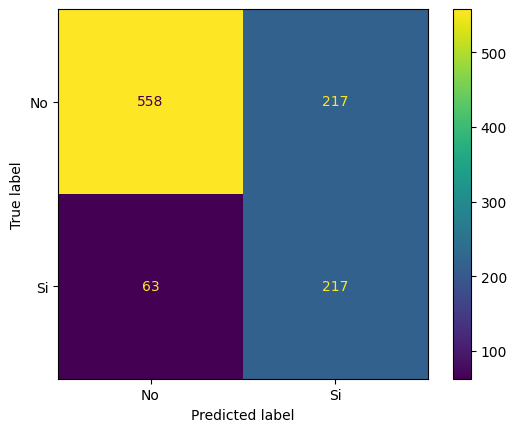

In [ ]:
mg3.optimizar().evaluar()

In [ ]:
import pickle

try:
  with open('champion.pkl','wb') as file:
    pickle.dump(mg3.modelo,file)
  print('Modelo serializado con éxito')
except Exception as e:
  print('Se presentó un error al almacenar el modelo: ',str(e))